In [1]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import urllib.request
import zipfile

In [2]:
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Use: {DEVICE}")

Use: mps


In [3]:
ZIP_URL = "https://storage.yandexcloud.net/academy.ai/CV/chess_yolo.zip"
ZIP_NAME = "chess_yolo.zip"
EXTRACT_DIR = "chess_yolo/chess_yolo"
if not os.path.exists(EXTRACT_DIR):
    print("Loading dataset...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_NAME)

    print("Unzip...")
    with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_NAME)
    print("Load comlete")
else:
    print("Dataset is exist.")

Dataset is exist.


In [4]:
SIZE = 320
BATCH_SIZE = 4
EPOCHS = 15
NUM_CLASSES = 12

TRAIN_IMAGES = "chess_yolo/chess_yolo/train/images"
TRAIN_LABELS = "chess_yolo/chess_yolo/train/labels"
VAL_IMAGES = "chess_yolo/chess_yolo/valid/images"
VAL_LABELS = "chess_yolo/chess_yolo/valid/labels"

CLASS_NAMES = [
    "white-king",
    "white-queen",
    "white-bishop",
    "white-knight",
    "white-rook",
    "white-pawn",
    "black-king",
    "black-queen",
    "black-bishop",
    "black-knight",
    "black-rook",
    "black-pawn",
]

ANCHORS = [
    [[116, 90], [156, 198], [373, 326]],  # Сетка 10x10 (крупные объекты)
    [[30, 61], [62, 45], [59, 119]],     # Сетка 20x20 (средние объекты)
    [[10, 13], [16, 30], [33, 23]]       # Сетка 40x40 (мелкие объекты)
]
GRID_SIZES = [10, 20, 40]

In [5]:
def iou_width_height(wh1, wh2):
    inter = torch.min(wh1[0], wh2[:, 0]) * torch.min(wh1[1], wh2[:, 1])
    union = wh1[0] * wh1[1] + wh2[:, 0] * wh2[:, 1] - inter
    return inter / union

class ChessDataset(Dataset):
    def __init__(self, images_path, labels_path, grid_sizes=GRID_SIZES, anchors=ANCHORS, num_classes=NUM_CLASSES):
        self.img_paths = sorted(glob.glob(os.path.join(images_path, "*.jpg")))
        self.labels_path = labels_path
        self.grid_sizes = grid_sizes
        self.anchors = anchors
        self.num_classes = num_classes

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img_filename = os.path.basename(img_path)
        label_filename = img_filename.replace(".jpg", ".txt")
        label_path = os.path.join(self.labels_path, label_filename)

        img = cv2.imread(img_path)
        orig_h, orig_w = img.shape[:2]
        img_resized = cv2.resize(img, (SIZE, SIZE))
        img_tensor = torch.tensor(img_resized).permute(2, 0, 1).float() / 255.0

        y_trues = [torch.zeros((S, S, 3, 6)) for S in self.grid_sizes]

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    parts = line.strip().split()

                    if len(parts) == 5:
                        class_idx, x, y, w, h = map(float, parts)
                        class_idx = int(class_idx)
                    elif len(parts) == 9:
                        # В датасете Roboflow разметка приходит как полигон: class x1 y1 x2 y2 x3 y3 x4 y4.
                        class_idx = int(float(parts[0]))
                        coords = list(map(float, parts[1:]))
                        xs = coords[0::2]
                        ys = coords[1::2]
                        x_min, x_max = min(xs), max(xs)
                        y_min, y_max = min(ys), max(ys)
                        x = (x_min + x_max) / 2.0
                        y = (y_min + y_max) / 2.0
                        w = x_max - x_min
                        h = y_max - y_min
                    else:
                        continue

                    # Логика подбора анкоров
                    flat_anchors = torch.tensor([a for scale in self.anchors for a in scale])
                    box_wh = torch.tensor([w * SIZE, h * SIZE])

                    # (Используем встроенную функцию iou_width_height, она у тебя должна быть выше)
                    ious = iou_width_height(box_wh, flat_anchors)
                    best_anchor_idx = torch.argmax(ious).item()

                    scale_idx = best_anchor_idx // 3
                    anchor_on_scale = best_anchor_idx % 3
                    S = self.grid_sizes[scale_idx]

                    grid_x = int(x * S)
                    grid_y = int(y * S)

                    if y_trues[scale_idx][grid_y, grid_x, anchor_on_scale, 4] == 0:
                        y_trues[scale_idx][grid_y, grid_x, anchor_on_scale, 0:4] = torch.tensor([x, y, w, h])
                        y_trues[scale_idx][grid_y, grid_x, anchor_on_scale, 4] = 1.0
                        y_trues[scale_idx][grid_y, grid_x, anchor_on_scale, 5] = class_idx

        return img_tensor, y_trues[0], y_trues[1], y_trues[2], torch.tensor([orig_w, orig_h])

In [6]:
class DBL(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, batch_norm=True):
        super().__init__()
        self.stride = stride
        self.batch_norm = batch_norm
        padding = kernel_size // 2 if stride == 1 else 0

        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, bias=not batch_norm)
        if self.batch_norm:
            self.bn = nn.BatchNorm2d(out_channels, eps=0.001)
        self.act = nn.LeakyReLU(0.1)

    def forward(self, x):
        if self.stride != 1:
            x = F.pad(x, (0, 1, 0, 1))
        x = self.conv(x)
        if self.batch_norm:
            x = self.bn(x)
        return self.act(x)

class ResUnit(nn.Module):
    def __init__(self, in_channels, filters):
        super().__init__()
        self.dbl1 = DBL(in_channels, filters // 2, 1)
        self.dbl2 = DBL(filters // 2, filters, 3)

    def forward(self, x):
        return x + self.dbl2(self.dbl1(x))

class ResN(nn.Module):
    def __init__(self, in_channels, filters, blocks):
        super().__init__()
        self.dbl = DBL(in_channels, filters, kernel_size=3, stride=2)
        self.blocks = nn.Sequential(*[ResUnit(filters, filters) for _ in range(blocks)])

    def forward(self, x):
        return self.blocks(self.dbl(x))

In [7]:
class Darknet(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.dbl1 = DBL(in_channels, 32, 3)
        self.res1 = ResN(32, 64, 1)
        self.res2 = ResN(64, 128, 2)
        self.res3 = ResN(128, 256, 8)
        self.res4 = ResN(256, 512, 8)
        self.res5 = ResN(512, 1024, 4)

    def forward(self, x):
        x = self.dbl1(x)
        x = self.res1(x)
        x = self.res2(x)
        route_1 = self.res3(x)
        route_2 = self.res4(route_1)
        route_3 = self.res5(route_2)
        return route_1, route_2, route_3

In [8]:
class YoloHead(nn.Module):
    def __init__(self, in_channels, skip_channels, filters):
        super().__init__()
        self.has_skip = skip_channels > 0
        if self.has_skip:
            self.dbl_up = DBL(in_channels, filters, 1)
            self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
            in_channels = filters + skip_channels

        self.block = nn.Sequential(
            DBL(in_channels, filters, 1),
            DBL(filters, filters * 2, 3),
            DBL(filters * 2, filters, 1),
            DBL(filters, filters * 2, 3),
            DBL(filters * 2, filters, 1)
        )

    def forward(self, x, x_skip=None):
        if self.has_skip and x_skip is not None:
            x = self.dbl_up(x)
            x = self.upsample(x)
            x = torch.cat([x, x_skip], dim=1)
        return self.block(x)

class YoloHeadOutput(nn.Module):
    def __init__(self, in_channels, filters, anchors_count, classes):
        super().__init__()
        self.anchors_count = anchors_count
        self.classes = classes
        self.dbl = DBL(in_channels, filters * 2, 3)
        self.conv_out = nn.Conv2d(filters * 2, anchors_count * (classes + 5), 1)

    def forward(self, x):
        x = self.dbl(x)
        x = self.conv_out(x)
        batch_size, _, grid_h, grid_w = x.shape
        x = x.view(batch_size, self.anchors_count, self.classes + 5, grid_h, grid_w)
        return x.permute(0, 3, 4, 1, 2) # [B, Grid, Grid, Anchors, Params]

class YOLOv3(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = Darknet(3)

        self.head1 = YoloHead(1024, 0, 512)
        self.out1 = YoloHeadOutput(512, 512, 3, num_classes)

        self.head2 = YoloHead(512, 512, 256)
        self.out2 = YoloHeadOutput(256, 256, 3, num_classes)

        self.head3 = YoloHead(256, 256, 128)
        self.out3 = YoloHeadOutput(128, 128, 3, num_classes)

    def forward(self, x):
        route_1, route_2, route_3 = self.backbone(x)

        h1 = self.head1(route_3)
        out1 = self.out1(h1)

        h2 = self.head2(h1, route_2)
        out2 = self.out2(h2)

        h3 = self.head3(h2, route_1)
        out3 = self.out3(h3)

        return out1, out2, out3

In [9]:
def yolo_boxes(pred, anchors, classes=NUM_CLASSES):
    device = pred.device
    grid_size = pred.shape[1]
    anchors_tensor = torch.tensor(anchors, dtype=pred.dtype, device=device).view(1, 1, 1, -1, 2)

    box_xy = torch.sigmoid(pred[..., 0:2])
    box_wh = pred[..., 2:4]
    score = torch.sigmoid(pred[..., 4:5])
    class_probs = torch.sigmoid(pred[..., 5:])

    grid_y, grid_x = torch.meshgrid(
        torch.arange(grid_size, device=device),
        torch.arange(grid_size, device=device),
        indexing='ij',
    )
    grid = torch.stack((grid_x, grid_y), dim=-1).float().unsqueeze(2)

    b_xy = (box_xy + grid) / float(grid_size)
    b_wh = (torch.exp(box_wh) * anchors_tensor) / float(SIZE)

    box_x1y1 = b_xy - b_wh / 2
    box_x2y2 = b_xy + b_wh / 2
    bbox = torch.cat([box_x1y1, box_x2y2], dim=-1)

    return bbox, score, class_probs

In [10]:
class YoloLoss(nn.Module):
    def __init__(self, classes=NUM_CLASSES):
        super().__init__()
        self.classes = classes
        self.bce = nn.BCELoss(reduction="none")
        self.mse = nn.MSELoss(reduction="none")
        self.noobj_scale = 0.05

    def forward(self, y_pred, y_true, scale_anchors):
        device = y_pred.device
        scale_anchors = scale_anchors.to(device)

        batch_size = y_pred.shape[0]
        grid_size = y_pred.shape[1]

        # Выход головы YOLOv3 уже имеет формат (B, S, S, A, 5 + C).
        pred_xy = torch.sigmoid(y_pred[..., 0:2])
        pred_wh = y_pred[..., 2:4]
        pred_obj = torch.sigmoid(y_pred[..., 4:5])
        pred_class = torch.sigmoid(y_pred[..., 5:])

        true_box = y_true[..., 0:4]
        true_obj = y_true[..., 4:5]
        true_class_idx = y_true[..., 5].long()

        grid_y, grid_x = torch.meshgrid(
            torch.arange(grid_size, device=device),
            torch.arange(grid_size, device=device),
            indexing='ij',
        )
        grid = torch.stack((grid_x, grid_y), dim=-1).float().unsqueeze(2)

        true_xy = true_box[..., 0:2] * grid_size - grid
        epsilon = 1e-7
        true_wh = torch.log((true_box[..., 2:4] * float(SIZE)) / scale_anchors + epsilon)
        true_wh = torch.where(torch.isinf(true_wh), torch.zeros_like(true_wh), true_wh)

        box_loss_scale = 2.0 - true_box[..., 2:3] * true_box[..., 3:4]
        obj_mask = true_obj.squeeze(-1)

        xy_loss = obj_mask.unsqueeze(-1) * box_loss_scale * self.mse(pred_xy, true_xy)
        wh_loss = obj_mask.unsqueeze(-1) * box_loss_scale * self.mse(pred_wh, true_wh)

        noobj_mask = 1.0 - obj_mask
        obj_loss = obj_mask.unsqueeze(-1) * self.bce(pred_obj, true_obj) + self.noobj_scale * noobj_mask.unsqueeze(-1) * self.bce(pred_obj, true_obj)

        true_class_one_hot = F.one_hot(true_class_idx, num_classes=self.classes).float()
        class_loss = obj_mask.unsqueeze(-1) * self.bce(pred_class, true_class_one_hot)

        total_loss = xy_loss.sum() + wh_loss.sum() + obj_loss.sum() + class_loss.sum()
        normalizer = obj_mask.sum().clamp(min=1.0)

        return total_loss / normalizer

In [11]:
train_dataset = ChessDataset(images_path=TRAIN_IMAGES, labels_path=TRAIN_LABELS)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

valid_dataset = ChessDataset(images_path=VAL_IMAGES, labels_path=VAL_LABELS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
print(len(train_dataset))
print(len(train_loader))
print(len(valid_dataset))
print(len(valid_loader))

606
152
58
15


In [19]:
model = YOLOv3().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = YoloLoss()

start_epoch = 0
CHECKPOINT_FILE = "yolov3_checkpoint.pth"

if os.path.exists(CHECKPOINT_FILE):
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    start_epoch = checkpoint["epoch"] + 1
    print(f"Продолжаем с эпохи {start_epoch}")

EPOCHS = 30
print("Запуск обучения модели...")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    epoch_loss = 0

    for imgs, y_true1, y_true2, y_true3, _ in train_loader:
        imgs = imgs.to(DEVICE)
        y_true1, y_true2, y_true3 = y_true1.to(DEVICE), y_true2.to(DEVICE), y_true3.to(DEVICE)

        optimizer.zero_grad()

        out1, out2, out3 = model(imgs)

        loss1 = criterion(out1, y_true1, torch.tensor(ANCHORS[0]).to(DEVICE))
        loss2 = criterion(out2, y_true2, torch.tensor(ANCHORS[1]).to(DEVICE))
        loss3 = criterion(out3, y_true3, torch.tensor(ANCHORS[2]).to(DEVICE))

        total_loss = loss1 + loss2 + loss3
        total_loss.backward()
        optimizer.step()

        epoch_loss += total_loss.item()

    print(f"Эпоха [{epoch+1}/{EPOCHS}] завершена. Средний Loss: {epoch_loss / len(train_loader):.4f}")

    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
    }
    torch.save(checkpoint, CHECKPOINT_FILE)
    print("Прогресс сохранен.")

Продолжаем с эпохи 15
Запуск обучения модели...
Эпоха [16/30] завершена. Средний Loss: 1.5458
Прогресс сохранен.
Эпоха [17/30] завершена. Средний Loss: 2.3112
Прогресс сохранен.
Эпоха [18/30] завершена. Средний Loss: 1.5990
Прогресс сохранен.
Эпоха [19/30] завершена. Средний Loss: 1.3716
Прогресс сохранен.
Эпоха [20/30] завершена. Средний Loss: 1.1883
Прогресс сохранен.
Эпоха [21/30] завершена. Средний Loss: 1.0665
Прогресс сохранен.
Эпоха [22/30] завершена. Средний Loss: 0.8007
Прогресс сохранен.
Эпоха [23/30] завершена. Средний Loss: 0.6479
Прогресс сохранен.
Эпоха [24/30] завершена. Средний Loss: 0.6094
Прогресс сохранен.
Эпоха [25/30] завершена. Средний Loss: 0.5371
Прогресс сохранен.
Эпоха [26/30] завершена. Средний Loss: 0.4795
Прогресс сохранен.
Эпоха [27/30] завершена. Средний Loss: 1.3790
Прогресс сохранен.
Эпоха [28/30] завершена. Средний Loss: 1.2320
Прогресс сохранен.
Эпоха [29/30] завершена. Средний Loss: 0.8367
Прогресс сохранен.
Эпоха [30/30] завершена. Средний Loss: 0.5

In [16]:
def letterbox_image(image, size=SIZE, color=(114, 114, 114)):
    orig_h, orig_w = image.shape[:2]
    scale = min(size / orig_w, size / orig_h)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), color, dtype=np.uint8)
    pad_x = (size - new_w) // 2
    pad_y = (size - new_h) // 2
    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized
    return canvas, scale, pad_x, pad_y


def box_iou(box1, box2):
    box1 = box1.unsqueeze(1)
    box2 = box2.unsqueeze(0)

    inter_x1 = torch.maximum(box1[..., 0], box2[..., 0])
    inter_y1 = torch.maximum(box1[..., 1], box2[..., 1])
    inter_x2 = torch.minimum(box1[..., 2], box2[..., 2])
    inter_y2 = torch.minimum(box1[..., 3], box2[..., 3])

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    area1 = torch.clamp(box1[..., 2] - box1[..., 0], min=0) * torch.clamp(box1[..., 3] - box1[..., 1], min=0)
    area2 = torch.clamp(box2[..., 2] - box2[..., 0], min=0) * torch.clamp(box2[..., 3] - box2[..., 1], min=0)
    union = area1 + area2 - inter_area + 1e-7
    return inter_area / union


def non_max_suppression(boxes, scores, iou_threshold=0.45):
    if boxes.numel() == 0:
        return torch.empty(0, dtype=torch.long, device=boxes.device)

    keep = []
    order = scores.argsort(descending=True)

    while order.numel() > 0:
        current = order[0]
        keep.append(current)

        if order.numel() == 1:
            break

        ious = box_iou(boxes[current].unsqueeze(0), boxes[order[1:]]).squeeze(0)
        order = order[1:][ious <= iou_threshold]

    return torch.stack(keep)


def detect_and_scale_boxes(img_path, model, conf_threshold=0.05, iou_threshold=0.45):
    orig_img = cv2.imread(img_path)
    if orig_img is None:
        raise FileNotFoundError(f"Не удалось прочитать изображение: {img_path}")

    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = orig_img.shape[:2]

    input_img, scale, pad_x, pad_y = letterbox_image(orig_img, SIZE)
    input_tensor = torch.tensor(input_img).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE) / 255.0

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)

    final_boxes = []
    final_scores = []

    for i, pred in enumerate(outputs):
        bbox, obj_score, class_probs = yolo_boxes(pred, ANCHORS[i], classes=NUM_CLASSES)
        class_score = class_probs.max(dim=-1).values
        scores = (obj_score.squeeze(-1) * class_score).reshape(-1)
        boxes = bbox.reshape(-1, 4)

        mask = scores > conf_threshold
        if mask.any():
            boxes = boxes[mask]
            scores = scores[mask]
            if scores.numel() > 200:
                topk = torch.topk(scores, k=200).indices
                boxes = boxes[topk]
                scores = scores[topk]
            final_boxes.append(boxes)
            final_scores.append(scores)

    if final_boxes:
        boxes_tensor = torch.cat(final_boxes, dim=0)
        scores_tensor = torch.cat(final_scores, dim=0)
        keep = non_max_suppression(boxes_tensor, scores_tensor, iou_threshold=iou_threshold)
        boxes_tensor = boxes_tensor[keep]

        boxes_tensor[:, [0, 2]] = (boxes_tensor[:, [0, 2]] * SIZE - pad_x) / scale
        boxes_tensor[:, [1, 3]] = (boxes_tensor[:, [1, 3]] * SIZE - pad_y) / scale
        boxes_tensor[:, [0, 2]] = boxes_tensor[:, [0, 2]].clamp(0, orig_w)
        boxes_tensor[:, [1, 3]] = boxes_tensor[:, [1, 3]].clamp(0, orig_h)

        fig, ax = plt.subplots(1, figsize=(12, 8))
        ax.imshow(orig_img)

        for box in boxes_tensor.cpu().numpy():
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='cyan', linewidth=3)
            ax.add_patch(rect)

        orientation = "Альбомная" if orig_w > orig_h else "Портретная"
        plt.title(f"Разрешение оригинала: {orig_w}x{orig_h} ({orientation})")
        plt.axis('off')
        plt.show()
    else:
        print(f"Объекты на картинке {orig_w}x{orig_h} не обнаружены (возможно, требуется дообучить сеть).")

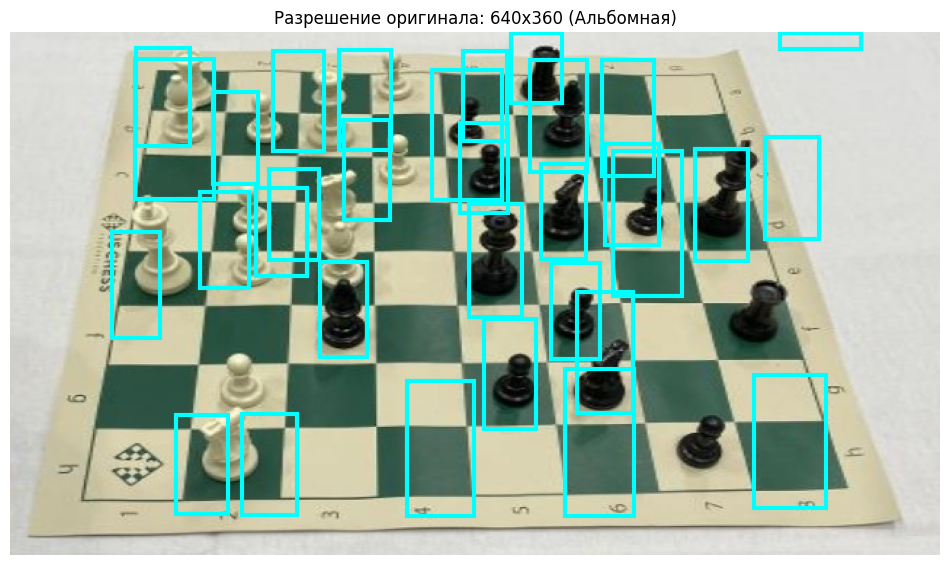

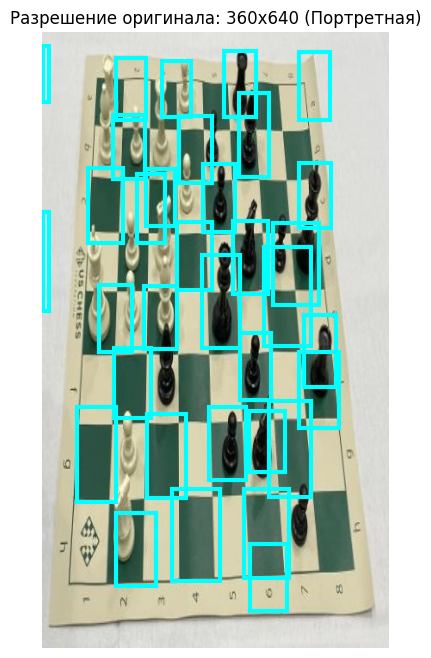

In [20]:
test_img_path = "chess_yolo/chess_yolo/test/fdcd6ada676799da8a870f58fdf548db_jpg.rf.b0ea8552b6106bb4ab62ca8957fca40d.jpg"
base_img = cv2.imread(test_img_path)

if base_img is None:
    raise FileNotFoundError(f"Не удалось прочитать тестовое изображение: {test_img_path}")

landscape_img_path = "/private/tmp/chess_demo_landscape.jpg"
portrait_img_path = "/private/tmp/chess_demo_portrait.jpg"
cv2.imwrite(landscape_img_path, cv2.resize(base_img, (640, 360)))
cv2.imwrite(portrait_img_path, cv2.resize(base_img, (360, 640)))

detect_and_scale_boxes(landscape_img_path, model)
detect_and_scale_boxes(portrait_img_path, model)